# Laboratorio 15: ANOVA con Iris

**Asignatura:** Analítica de Datos  
**Docente:** Luis Miguel Gómez Meneses  
**Universidad Cooperativa de Colombia**

## Objetivo

Aplicar ANOVA de un factor para evaluar si existen diferencias
en el ancho medio del sépalo entre las especies **setosa**,
**versicolor** y **virginica**.

- **Variable numérica:** ancho del sépalo, medido en centímetros.
- **Variable de agrupación:** especie de la flor.

## 1. Importación de librerías

Utilizaremos:

- **Pandas:** organizar y resumir los datos.
- **Matplotlib:** construir gráficos.
- **Scikit-learn:** cargar el dataset Iris.
- **SciPy:** aplicar ANOVA y las pruebas de apoyo para revisar supuestos.

### Fuente y documentación

- [Descripción del dataset Iris — UCI](https://archive.ics.uci.edu/dataset/53/iris)
- [Documentación de load_iris — Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)

En este laboratorio utilizamos la versión incluida en Scikit-learn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy import stats

## 2. Carga del dataset Iris

Iris contiene **150 flores**, distribuidas en tres especies:
**setosa**, **versicolor** y **virginica**, con 50 registros por especie.

Cada fila representa una flor e incluye cuatro medidas en centímetros:
longitud y ancho del sépalo, y longitud y ancho del pétalo.

Cargaremos el dataset desde Scikit-learn y asignaremos nombres
en español a las columnas.

**En este laboratorio analizaremos `ancho_sepalo`, agrupado por `especie`.**

In [2]:
iris = load_iris(as_frame=True)
df = iris.data.copy()
df.columns = [
    "longitud_sepalo",
    "ancho_sepalo",
    "longitud_petalo",
    "ancho_petalo"
]
df["especie"] = iris.target.map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})
df.head()

,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Resumen del ancho del sépalo por especie

Calcularemos para cada especie:

- **Cantidad de flores (`n`):** número de observaciones.
- **Media:** ancho promedio del sépalo, en centímetros.
- **Desviación estándar:** cuánto varían los anchos alrededor
  de la media dentro de cada especie.

Esta tabla permite observar las diferencias entre las medias
y la variabilidad dentro de los grupos.

**Que las medias muestrales sean diferentes no basta para concluir
que las medias poblacionales también lo son. Para evaluar esa
diferencia utilizaremos ANOVA.**

In [3]:
resumen = df.groupby("especie")["ancho_sepalo"].agg(
    n="count",
    media="mean",
    desviacion_estandar="std"
)
resumen.round(3)

,n,media,desviacion_estandar
especie,,,
setosa,50,3.428,0.379
versicolor,50,2.770,0.314
virginica,50,2.974,0.322


## 4. Comparación visual entre especies

Representaremos el ancho del sépalo mediante un diagrama de cajas
o **boxplot** para cada especie.

- **Caja:** contiene el 50 % central de los datos.
- **Línea dentro de la caja:** representa la mediana.
- **Rombo naranja:** representa la media, que es lo que compara ANOVA.
- **Puntos fuera de los bigotes:** posibles valores atípicos;
  no necesariamente son errores.

Observa la posición de las medias y la dispersión de cada grupo.
El gráfico orienta la comparación, pero no reemplaza la prueba ANOVA.

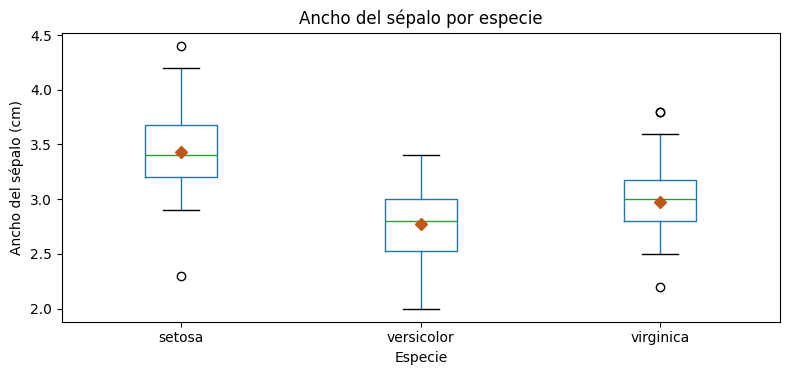

In [4]:
df.boxplot(
    column="ancho_sepalo",
    by="especie",
    figsize=(8, 4),
    grid=False,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "#C2571A",
        "markeredgecolor": "#C2571A",
        "markersize": 6
    }
)
plt.suptitle("")
plt.title("Ancho del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Ancho del sépalo (cm)")
plt.tight_layout()
plt.show()

### Interpretación del boxplot

En las flores analizadas se observa que:

- **Setosa** presenta el mayor ancho promedio del sépalo.
- **Versicolor** presenta el menor promedio.
- **Virginica** presenta un promedio intermedio.
- Dentro de cada especie existe variabilidad: las flores de una
  misma especie no tienen todas el mismo ancho del sépalo.
- Los valores de las especies se superponen parcialmente.

Por tanto, las medias de los tres grupos son diferentes en esta
muestra. ANOVA permitirá evaluar si estas diferencias aportan
evidencia estadística contra la hipótesis de igualdad de las
medias poblacionales, bajo los supuestos del análisis.

### Preguntas de análisis

1. ¿Qué especie presenta el mayor ancho promedio del sépalo?
   ¿Qué elemento del boxplot permite identificar ese promedio?

2. Si elegimos una flor setosa y una virginica, ¿podemos asegurar
   que la setosa tendrá un sépalo más ancho? Justifica tu respuesta
   utilizando la dispersión y la superposición de los datos.

3. Si las medias de las tres especies se ven diferentes en el
   gráfico, ¿qué información adicional necesitamos obtener
   mediante ANOVA?

**Escribe tus respuestas en una celda de texto. Relaciona tus
explicaciones con lo que observas en el gráfico.**

## 5. Hipótesis y preparación de los grupos

Queremos evaluar si el ancho medio del sépalo es igual entre
las tres especies.

**Hipótesis nula (H₀):** las tres medias poblacionales son iguales.

$$
H_0:\ \mu_{\text{setosa}} =
\mu_{\text{versicolor}} =
\mu_{\text{virginica}}
$$

**Hipótesis alternativa (H₁):** al menos una de las medias
poblacionales es diferente.

Utilizaremos un **nivel de significancia de 0,05**.

Para realizar el análisis, separaremos los valores de
`ancho_sepalo` en tres grupos, uno por especie.

In [5]:
alpha = 0.05
setosa = df.loc[df["especie"] == "setosa", "ancho_sepalo"]
versicolor = df.loc[df["especie"] == "versicolor", "ancho_sepalo"]
virginica = df.loc[df["especie"] == "virginica", "ancho_sepalo"]
print("Flores setosa:", len(setosa))
print("Flores versicolor:", len(versicolor))
print("Flores virginica:", len(virginica))

Flores setosa: 50
Flores versicolor: 50
Flores virginica: 50


## 6. Revisión de los supuestos de ANOVA

El ANOVA clásico considera tres supuestos:

1. **Independencia:** las observaciones deben ser independientes.
   Esto depende de cómo se recolectaron los datos; en este
   ejercicio lo asumimos, pero no lo verificamos con estas pruebas.

2. **Normalidad dentro de cada especie:** utilizaremos Shapiro-Wilk.
   Su hipótesis nula indica que los datos del grupo provienen
   de una distribución normal.

3. **Igualdad de varianzas entre especies:** utilizaremos Levene.
   Su hipótesis nula indica que las tres varianzas poblacionales
   son iguales.

### ¿Cómo interpretamos los resultados?

Para cada prueba:

- Si **p < 0,05**, encontramos evidencia contra su hipótesis nula.
- Si **p ≥ 0,05**, no encontramos evidencia suficiente para rechazarla.
  Esto no demuestra que el supuesto se cumpla perfectamente.

**Estos valores p evalúan los supuestos; todavía no comparan
las medias mediante ANOVA.**

In [6]:
resultados_supuestos = pd.DataFrame({
    "Prueba": [
        "Shapiro-Wilk: setosa",
        "Shapiro-Wilk: versicolor",
        "Shapiro-Wilk: virginica",
        "Levene: las tres especies"
    ],
    "p_valor": [
        stats.shapiro(setosa).pvalue,
        stats.shapiro(versicolor).pvalue,
        stats.shapiro(virginica).pvalue,
        stats.levene(setosa, versicolor, virginica, center="median").pvalue
    ]
})
resultados_supuestos.round(4)

,Prueba,p_valor
0,Shapiro-Wilk: setosa,0.2715
1,Shapiro-Wilk: versicolor,0.3380
2,Shapiro-Wilk: virginica,0.1809
3,Levene: las tres especies,0.5555


## 7. Aplicación de ANOVA de un factor

Compararemos las medias poblacionales del ancho del sépalo:

- **H₀:** las tres medias son iguales.
- **H₁:** al menos una media es diferente.

Obtendremos:

- **Estadístico F:** compara la variabilidad entre los grupos
  con la variabilidad dentro de ellos.
- **Valor p:** lo compararemos con el nivel de significancia
  establecido: α = 0,05.

### Regla de decisión

- Si **p < 0,05**, rechazamos H₀: hay evidencia de que al menos
  una media poblacional es diferente.
- Si **p ≥ 0,05**, no rechazamos H₀: no hay evidencia suficiente
  para concluir que las medias poblacionales difieren.

ANOVA es una comparación global: por sí solo no identifica
cuáles pares de especies presentan diferencias.

In [7]:
F_anova, p_anova = stats.f_oneway(setosa, versicolor, virginica)
print(f"Estadístico F: {F_anova:.4f}")
print(f"Valor p: {p_anova:.4e}")
print(f"Nivel de significancia: {alpha}")

Estadístico F: 49.1600
Valor p: 4.4920e-17
Nivel de significancia: 0.05


## 8. Conclusión del laboratorio

Escribe un párrafo breve que responda:

¿Existe evidencia estadística de diferencias en el ancho medio
del sépalo entre las especies?

Incluye el estadístico F, el valor p, la decisión sobre H₀
y la interpretación en el contexto de las flores.

Explica también por qué ANOVA, por sí solo, no permite identificar
cuáles pares de especies presentan diferencias.